In [613]:
import pandas as pd
df = pd.read_csv("course_final.csv", encoding = "utf-8", index_col= 0)

In [614]:
df.info()

<class 'pandas.DataFrame'>
Index: 533993 entries, HarvardX/PH207x/2012_Fall to MITx/6.00x/2013_Spring
Data columns (total 30 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   userid_DI             533993 non-null  str    
 1   registered            533993 non-null  int64  
 2   viewed                533993 non-null  int64  
 3   explored              533993 non-null  int64  
 4   certified             533993 non-null  int64  
 5   final_cc_cname_DI     533993 non-null  str    
 6   LoE_DI                533993 non-null  str    
 7   YoB                   452939 non-null  float64
 8   gender                533993 non-null  str    
 9   grade                 483483 non-null  float64
 10  start_time_DI         533993 non-null  str    
 11  last_event_DI         533993 non-null  str    
 12  nevents               532186 non-null  float64
 13  ndays_act             532186 non-null  float64
 14  nplay_video           348922

In [615]:
df.describe()

,registered,viewed,explored,certified,YoB,grade,nevents,ndays_act,nplay_video,nchapters,...,viewed_missing_flag,duration,fast_completion_flag,start_year,age_raw,age_cleaned,age_final,age,exam_flag,LoE_num
count,533993.0,533993.000000,533993.000000,533993.000000,452939.000000,483483.000000,532186.000000,532186.000000,348922.000000,475783.000000,...,533993.000000,533993.000000,533993.000000,533993.000000,452939.000000,452287.000000,452939.000000,452939.000000,533993.000000,446134.000000
mean,1.0,0.609298,0.070383,0.033096,1985.321542,0.040998,357.682042,4.825112,60.313540,2.642255,...,0.003384,40.071141,0.000777,2012.562206,27.240527,27.273870,27.266418,27.266418,0.905411,2.915301
std,0.0,0.487908,0.255792,0.178887,8.857944,0.165467,1390.863751,11.151017,314.961586,4.349631,...,0.058073,68.059473,0.027867,0.496116,8.867960,8.828384,8.825707,8.825707,0.292647,0.857424
min,1.0,0.000000,0.000000,0.000000,1931.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,2012.000000,0.000000,13.000000,13.000000,13.000000,0.000000,1.000000
25%,1.0,0.000000,0.000000,0.000000,1982.000000,0.000000,1.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,2012.000000,21.000000,21.000000,21.000000,21.000000,1.000000,2.000000
50%,1.0,1.000000,0.000000,0.000000,1988.000000,0.000000,11.000000,1.000000,1.000000,1.000000,...,0.000000,1.000000,0.000000,2013.000000,25.000000,25.000000,25.000000,25.000000,1.000000,3.000000
75%,1.0,1.000000,0.000000,0.000000,1991.000000,0.000000,105.000000,4.000000,20.000000,3.000000,...,0.000000,54.000000,0.000000,2013.000000,30.000000,30.000000,30.000000,30.000000,1.000000,4.000000
max,1.0,1.000000,1.000000,1.000000,2013.000000,1.010000,197757.000000,205.000000,98517.000000,48.000000,...,1.000000,409.000000,1.000000,2013.000000,82.000000,82.000000,82.000000,82.000000,1.000000,5.000000


In [616]:
missing_summary = pd.DataFrame({
    'missing_count' : df.isnull().sum(),
    'missing_ratio(%)' : (df.isnull().mean()*100).round(2)
}).sort_values(by='missing_ratio(%)', ascending=False)
missing_summary

,missing_count,missing_ratio(%)
nplay_video,185071,34.66
LoE_num,87859,16.45
age_cleaned,81706,15.30
age_raw,81054,15.18
YoB,81054,15.18
age_final,81054,15.18
age,81054,15.18
nchapters,58210,10.90
grade,50510,9.46
ndays_act,1807,0.34


In [617]:
df.head()

,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,gender,grade,...,start_year,age_raw,age_missing_original,age_invalid,age_cleaned,age_final,age,age_group,exam_flag,LoE_num
course_id,,,,,,,,,,,,,,,,,,,,,
HarvardX/PH207x/2012_Fall,MHxPC130275857,1,1,1,0,United States,unknown,NaN,unknown,0.0,...,2012,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN
HarvardX/CB22x/2013_Spring,MHxPC130539455,1,1,0,0,France,unknown,NaN,unknown,0.0,...,2013,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN
HarvardX/CB22x/2013_Spring,MHxPC130088379,1,1,0,0,United States,unknown,NaN,unknown,0.0,...,2013,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN
HarvardX/ER22x/2013_Spring,MHxPC130088379,1,1,0,0,United States,unknown,NaN,unknown,0.0,...,2013,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN
HarvardX/ER22x/2013_Spring,MHxPC130198098,1,1,0,0,United States,unknown,NaN,unknown,0.0,...,2013,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN


In [618]:
# 각 단계별 총 인원 합계
n_reg = df['registered'].sum()
n_view = df['viewed'].sum()
n_exp = df['explored'].sum()

print(n_reg)
print(n_view)
print(n_exp)

533993
325361
37584


In [619]:
# 각 단계별 총 인원 합계
n_reg = df['registered'].sum()
n_view = df['viewed'].sum()
n_exp = df['explored'].sum()

# 등록자 중 실제 강의를 본 비율
reg_to_view = (n_view / n_reg) * 100
# 이탈률
drop_out_reg_to_view = 100 - reg_to_view

# 강의를 본 사람 중 탐색한 비율
view_to_exp = (n_exp / n_view) * 100
# 이탈률
drop_out_view_to_exp = 100 - view_to_exp

# 전체 등록자 대비 탐색 비율
total_conversion = (n_exp / n_reg) * 100

print(f"========== 단계별 참여 및 이탈 구조 ==========")
print(f"registered -> viewed 전환율 : {reg_to_view:.2f}%")
print(f"registered -> viewed 이탈률 : {drop_out_reg_to_view:.2f}%")
print()
print(f"viewed -> explored 전환율 : {view_to_exp:.2f}%")
print(f"viewed -> explored 이탈률 : {drop_out_view_to_exp:.2f}%")
print()
print(f"최종 explored 전환율 : {total_conversion:.2f}%")

========== 단계별 참여 및 이탈 구조 ==========
registered -> viewed 전환율 : 60.93%
registered -> viewed 이탈률 : 39.07%

viewed -> explored 전환율 : 11.55%
viewed -> explored 이탈률 : 88.45%

최종 explored 전환율 : 7.04%


In [620]:
import plotly.graph_objects as go

stages = ["Registered", "Viewed", "Explored"]
counts = [n_reg, n_view, n_exp]

fig = go.Figure(go.Funnel(
    y = stages,
    x = counts,
    textinfo = "value+percent initial+percent previous",
    marker = {"color": ["#636EFA", "#EF553B", "#00CC96"]}
))

fig.update_layout(title_text='학습 퍼널 및 단계별 전환율 진단')
fig.show() 

In [621]:
# # 이탈자 유형 세분화

# # Step 1. 진입 전 이탈
# step1 = ((df['registered'] == 1) & (df['viewed'] == 0)).sum()

# # Step 2-1. 진입 직후 이탈
# step2_1 = ((df['viewed'] == 1) & (df['nevents'].isna()) & (df['explored'] == 0)).sum()

# # Step 2-2. 탐색 시도 후 이탈
# step2_2 = ((df['viewed'] == 1) & (df['nevents'] > 0) & (df['explored'] == 0)).sum()

# print(f"진입 전 이탈 : {step1:,}명")
# print(f"진입 직후 이탈 : {step2_1:,}명")
# print(f"탐색 시도 후 이탈 : {step2_2:,}명")

In [622]:
# target_group = df[(df['viewed'] == 1) & (df['nevents'] > 0) & (df['explored'] == 0)]

# # 확인할 지표 리스트
# check_cols = ['nchapters', 'ndays_act', 'nplay_video']

# print(f"===== [탐색 시도 후 이탈자] ({len(target_group):,}명) 대상 활동 지표 기록 현황 =====")

# for col in check_cols:
#     exists_count = target_group[col].notna().sum()
#     exists_ratio = (exists_count / len(target_group)) * 100
    
#     print(f"[{col}] 기록 존재 : {exists_count:,}명 ({exists_ratio:.2f}%)")
#     print(f"[{col}] 결측(NaN) -> 도달 못함 : {len(target_group) - exists_count:,}명")
#     print("-" * 50)

In [623]:
# # 탐색 시도 후 이탈자 행동 분석
# avg_video_target = target_group['nplay_video'].mean()
# print(f"탐색 시도 후 이탈자 평균 영상 재생 횟수 : {avg_video_target:.2f}회")

In [624]:
# # explored 그룹 행동 분석
# step3_total = df[df['explored'] == 1]
# avg_video = step3_total['nplay_video'].mean()
# print(f"explored 유저 평균 영상 재생 횟수 : {avg_video:.2f}회")

In [625]:
# # explored 유형 활동 중심 세분화
# step3_total = df[df['explored'] == 1]
# step3_total_count = (df['explored'] == 1).sum()

# # Step 3-1. 영상 몰입형 
# step3_1 = (step3_total['nplay_video'] > avg_video).sum()

# # Step 3-2 일반 달성자
# step3_2 = (step3_total['nplay_video'] <= avg_video).sum()

# print(f"=== Step 3. explored 집단 상세 분석 ===")
# print(f"explored 유저 수 : {step3_total_count:,}명")
# print(f"영상 몰입형: {step3_1:,}명")
# print(f"일반 달성자: {step3_2:,}명")
# print()
# missing_count = step3_total['nplay_video'].isna().sum()
# print(f"영상 기록이 없는(NaN) explored 유저 : {missing_count:,}명")

In [626]:
# from scipy import stats

# # 1. explored 내 두 그룹 정의
# success_group = df[df['explored'] == 1]
# success_video_high = success_group[success_group['nplay_video'] > success_group['nplay_video'].mean()]
# success_video_nan = success_group[success_group['nplay_video'].isna()]

# # 2. 전체 이벤트(nevents) 평균 차이 검정
# t_stat, p_val = stats.ttest_ind(success_video_high['nevents'], success_video_nan['nevents'], equal_var=False)

# print(f"영상 몰입형 평균 이벤트 발생 횟수 : {success_video_high['nevents'].mean():.2f}회")
# print(f"영상 기록이 없는 (NaN) 평균 이벤트 발생 횟수: {success_video_nan['nevents'].mean():.2f}회")
# print(f"P-value: {p_val:.4e}")

# if p_val < 0.05:
#     print("\n결론: 두 집단의 활동 방식이 통계적으로 확연히 다름")
# else:
#     print("\n결론: 활동량 차이가 크지 않음 (다른 요인이 있을 수 있음)")

In [627]:
# import pandas as pd
# from scipy.stats import chi2_contingency

# # 1.  explored 내 두 그룹 준비
# success_group = df[df['explored'] == 1].copy()
# success_video_high = success_group[success_group['nplay_video'] > success_group['nplay_video'].mean()].copy()
# success_video_nan = success_group[success_group['nplay_video'].isna()].copy()

# # 2. 비교할 변수 리스트
# vars_to_check = ['nforum_posts', 'exam_flag', 'nchapters']

# for var in vars_to_check:
#     # '기록 있음' 여부를 새로운 컬럼으로 생성 (NaN이면 0, 값이 있으면 1)
#     success_video_high['has_record'] = success_video_high[var].notna().astype(int)
#     success_video_nan['has_record'] = success_video_nan[var].notna().astype(int)
    
#     # 교차표 생성
#     high_counts = success_video_high['has_record'].value_counts()
#     nan_counts = success_video_nan['has_record'].value_counts()
    
#     # 통계 검정 (데이터가 양쪽 그룹에 모두 존재할 때만)
#     contingency = pd.DataFrame([high_counts, nan_counts], index=['High_Effort', 'Video_NaN'])
#     chi2, p, dof, expected = chi2_contingency(contingency.fillna(0))
    
#     print(f"[{var}] 기록 보유 비율 차이 검정")
#     print(f"- 영상 몰입형 기록 보유율: {success_video_high['has_record'].mean():.2%}")
#     print(f"- 영상 기록이 없는 (NaN) 기록 보유율: {success_video_nan['has_record'].mean():.2%}")
#     print(f"- P-value: {p:.4e}")
#     print("-" * 30)

In [628]:
# # 1. 성공자(효율형) 데이터
# low_effort_success = df[(df['explored'] == 1) & (df['nplay_video'].isna())]
# # 2. 이탈자 데이터
# target_group = df[(df['viewed'] == 1) & (df['nevents'] > 0) & (df['explored'] == 0)]

# # 비교할 지표 리스트
# metrics = ['ndays_act', 'duration', 'nchapters']

# for m in metrics:
#     success_mean = low_effort_success[m].mean()
#     churn_mean = target_group[m].mean()
    
#     # 이탈자 중 성공자 평균도 못 채우는 비율
#     under_ratio = (target_group[m] < success_mean).mean() * 100
    
#     print(f"[{m}] 기준")
#     print(f"- 성공자 평균: {success_mean:.2f}")
#     print(f"- 이탈자 평균: {churn_mean:.2f}")
#     print(f"- 기준 미달 이탈자 비율: {under_ratio:.1f}%")
#     print("-" * 30)

In [629]:
# # 그룹별 explored 유저 학력 분포
# # 영상 몰입형 
# video_high = step3_total[step3_total['nplay_video'] > step3_total['nplay_video'].mean()]

# # 영상 기록 NaN형
# video_zero = step3_total[step3_total['nplay_video'].isna()]

# # 학력 분포 
# print("=== [영상 몰입형] 학력 비중 ===")
# print(video_high['LoE_DI'].value_counts(normalize=True) * 100)

# print("\n=== [영상 기록 NaN형] 학력 비중 ===")
# print(video_zero['LoE_DI'].value_counts(normalize=True) * 100)

In [630]:
# import matplotlib.pyplot as plt
# import pandas as pd

# data = {
#     'Category': ['Video Immersed (High)', 'Video Skip (NaN)'],
#     "Master's": [27.4, 18.1],
#     'Secondary': [15.4, 28.7]
# }
# plot_df = pd.DataFrame(data).set_index('Category')

# # 시각화
# ax = plot_df.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#4A90E2', '#FF6B6B'])
# plt.title('Learning Style by Education: Master vs Secondary', fontsize=15)
# plt.ylabel('Proportion (%)')
# plt.xticks(rotation=0)
# plt.legend(title='Education Level')

# # 수치 표시
# for p in ax.patches:
#     width, height = p.get_width(), p.get_height()
#     x, y = p.get_xy() 
#     ax.text(x+width/2, y+height/2, f'{height:.1f}%', ha='center', va='center', color='white', fontweight='bold')

# plt.tight_layout()
# plt.show()

In [631]:
# # 학력에 따른 학습 스타일 차이 검정
# # 학력별 다른 학습 가이드 제공
# !pip install scipy
# from scipy.stats import chi2_contingency

# from scipy import stats

# # 그룹 복사 및 그룹 표시용 컬럼 추가 
# v_high = video_high.copy()
# v_zero = video_zero.copy()

# v_high['group'] = 'High_Video'
# v_zero['group'] = 'Zero_Video'

# # 인덱스 무시하고 합치기 
# compare_df = pd.concat([v_high, v_zero], ignore_index=True)

# # 교차표(Contingency Table) 생성
# contingency_table = pd.crosstab(compare_df['LoE_DI'], compare_df['group'])

# # 카이제곱 검정 실시
# chi2, p, dof, expected = chi2_contingency(contingency_table)

# print(f"카이제곱 통계량: {chi2:.4f}")
# print(f"P-value: {p:.4e}")

# if p < 0.05:
#     print("결과: 학력에 따른 학습 스타일 차이는 통계적으로 매우 유의미함 (귀무가설 기각)")
# else:
#     print("결과: 학력과 학습 스타일 간의 유의미한 차이가 발견되지 않음")

In [632]:
# ### 수정 필요
# from scipy.stats import mannwhitneyu
# # 탐색 시도 후 이탈자 
# churn_group_video = df[(df['viewed'] == 1) & (df['nevents'] > 0) & (df['explored'] == 0)]['nplay_video'].fillna(0)

# # explored 된 유저
# success_group_video = df[df['explored'] == 1]['nplay_video'].fillna(0)

# # Mann-Whitney U 검정 실시
# stat, p = mannwhitneyu(churn_group_video, success_group_video)

# print("=== 이탈자 vs explored 유저 영상 재생 횟수 차이 검정 ===")
# print(f"탐색 시도 후 이탈자 평균 영상 재생 횟수 : {churn_group_video.mean():.2f}회")
# print(f"explored 유저 평균 영상 재생 횟수 : {success_group_video.mean():.2f}회")
# print(f"P-value: {p:.4e}")

# # 3. 결과 해석
# if p < 0.05:
#     print("\n 결과 : 두 집단 간 영상 재생 횟수 차이는 통계적으로 매우 유의미함")
#     print(f" 인사이트 : explored 유저는 탐색 시도 후 이탈자보다 약 {success_group_video.mean()/churn_group_video.mean():.1f}배 더 많은 영상을 소비함")
# else:
#     print("\n 결과 : 두 집단 간 통계적으로 유의미한 차이가 발견되지 않음")

In [633]:
# # explored 유저 분석
# df['grade'] = pd.to_numeric(df['grade'], errors='coerce')

# target = df[df['explored'] == 1]
# print("========== Explored 유저의 grade 통계 ==========")
# print(target['grade'].describe())

In [634]:
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# # explored 된 유저 분석
# target = df[df['explored'] == 1]
# no_exam_rate = (len(target[target['exam_flag'] == 0]) / len(target)) * 100
# print(f"explored 된 유저 중 시험 미응시 비율 : {no_exam_rate:.2f}%")
# print()

# # 시각화 (0점 포함 vs 0점 제외)
# plt.figure(figsize=(12, 5))

# # [왼쪽] 전체 분포 (0점 포함)
# plt.subplot(1, 2, 1)
# sns.histplot(target['grade'].dropna(), bins=20, color='skyblue', kde=True)
# plt.title('Grade Distribution (All Explored)')

# # [오른쪽] 실제 성취도 (0점 제외)
# plt.subplot(1, 2, 2)
# active_target = target[target['grade'] > 0]
# sns.histplot(active_target['grade'], bins=20, color='salmon', kde=True)
# plt.title('Grade Distribution (Excluding 0)')

# plt.tight_layout()
# plt.show()

### 이탈 유형 재정의

In [635]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# df = df.reset_index()
# df = df.loc[:, ~df.columns.duplicated()]

# # 임계값 설정
# thresholds = {
#     'nchapters': 9,
#     'ndays_act': 18,
#     'nevents': 1274,
#     'nplay_video': 199
# }

# # step 2 유저 그룹 분류 
# # viewed는 했지만 explored는 못한 유저들 중, 설정한 기준을 하나라도 넘긴 '고관여 탐색 이탈자' 추출
# target_condition = (df['viewed'] == 1) & (df['explored'] == 0)
# df['is_high_effort_leaver'] = target_condition & (
#     #(df['nchapters'] >= thresholds['nchapters']) | 
#     (df['ndays_act'] >= thresholds['ndays_act']) |
#     (df['nevents'] >= thresholds['nevents']) |
#     (df['nplay_video'] >= thresholds['nplay_video'])
# )

# # 임계값 기준 분포 확인
# features = ['nchapters', 'ndays_act', 'nevents', 'nplay_video']
# plt.figure(figsize=(15, 10))

# for i, col in enumerate(features, 1):
#     plt.subplot(2, 2, i)
#     sns.boxplot(x='is_high_effort_leaver', y=col, data=df[target_condition])
#     plt.axhline(thresholds[col], color='red', linestyle='--', label=f'Threshold ({thresholds[col]})')
#     plt.title(f'Distribution of {col} (Viewed but not Explored)')
#     plt.legend()

# plt.tight_layout()
# plt.show()

- 고관여 탐색 이탈자 nevents는 임계값을 초과할 정도로 매우 활발하나, nchapters의 중앙값이 임계값에 도달하지 못하는 것으로 보아, 이는 활동의 양이 성과로 전환되지 못하는 학습 정체 현상이 발생하고 있음을 시사함 따라서 두 그룹의 학습 효율성을 산출하여 통계적 차이를 검정하고자 함 

In [636]:
# # 이탈자 유형 세분화
# # Step 1. 진입 전 이탈
# r_step1 = ((df['registered'] == 1) & (df['viewed'] == 0)).sum()

# # Step 2. 탐색 중 이탈
# # 2-1. 단순 탐색 후 이탈 (기준치 미달)
# r_step2_1 = ((df['viewed'] == 1) & (df['explored'] == 0) & (df['is_high_effort_leaver'] == False)).sum()

# # 2-2. 고관여 탐색 후 이탈 (기준치 초과)
# r_step2_2 = ((df['viewed'] == 1) & (df['explored'] == 0) & (df['is_high_effort_leaver'] == True)).sum()

# print(f"진입 전 이탈 : {r_step1:,}명")
# print(f"단순 탐색 후 이탈 : {r_step2_1:,}명")
# print(f"고관여 탐색 후 이탈 : {r_step2_2:,}명")

In [637]:
# # Viewed -> Explored 단계 이탈자 중 고관여 탐색 유저의 비율
# leaver_count = df[target_condition].shape[0]
# high_effort_count = df['is_high_effort_leaver'].sum()
# ratio = (high_effort_count / leaver_count) * 100

# print(f"탐색 단계 이탈자 중 고관여 탐색 유저 비율: {ratio:.2f}%")

In [638]:
# import numpy as np
# from scipy import stats

# # 고관여 탐색 이탈자들의 상당수가 많은 활동량에도 불구하고 9챕터 이상의 진도를 나가지 못하는 학습 정체 현상을 보임
# # 탐색 단계 이탈자 중 활동이 아예 없는 유저는 효율성(nchapters/nevents) 계산 자체가 무의미하므로 제외
# active_user = df[(df['nevents'] > 0) & (df['nevents'].notna()) & (df['nchapters'] > 0) & (df['nchapters'].notna()) & (df['viewed'] == 1) & (df['explored'] == 0)].copy()

# # 효율성 지표 
# active_user['learning_efficiency'] = active_user['nchapters'] / active_user['nevents']

# # 그룹 나누기
# group_high = active_user[active_user['is_high_effort_leaver'] == True]['learning_efficiency']
# group_low = active_user[active_user['is_high_effort_leaver'] == False]['learning_efficiency']

# # 통계 검정 (Mann-Whitney U)
# u_stat, p_val = stats.mannwhitneyu(group_low, group_high, alternative='two-sided')

# print(f"고관여 탐색 이탈자 효율성 평균: {group_high.mean():.4f}")
# print(f"단순 탐색 이탈자 효율성 평균: {group_low.mean():.4f}")
# print(f"P-value: {p_val:.10f}")
# print()
# if p_val < 0.05:
#     ratio = group_low.mean() / group_high.mean()
#     print(f"결과 : 학습 정체 현상이 통계적으로 매우 유의미하게 확인")
#     print(f"효율성 분석 : 고관여 탐색 이탈자의 학습 효율은 단순 탐색 이탈자 대비 {1/ratio:.1%} 수준에 불과")
#     print(f"결론 : 고관여 탐색 유저들은 동일 진도 달성을 위해 단순 탐색 유저들 보다 노력 대비 효율이 약 {ratio:.1f}배 낮음")

In [639]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd
# # 학력별 단순 탐색 / 고관여 탐색 이탈자 수 비교
# leavers_df = df[(df['viewed'] == 1) & (df['explored'] == 0)].copy()

# plt.figure(figsize=(14, 7))
# ax = sns.countplot(x='LoE_DI', hue='is_high_effort_leaver', data=leavers_df, 
#                    order=leavers_df['LoE_DI'].value_counts().index, palette='viridis')

# # 막대 그래프 위에 실제 인원수 표시
# for p in ax.patches:
#     height = p.get_height()
#     if height > 0: 
#         ax.text(p.get_x() + p.get_width()/2., height + 100, 
#                 f'{int(height):,}',
#                 ha="center", fontsize=10, fontweight='bold')

# plt.title('Leaver Type by Education Level (Actual Count)', fontsize=15)
# plt.xlabel('Level of Education')
# plt.ylabel('Number of Users')
# plt.legend(title='High Effort Leaver', labels=['False (Low)', 'True (High)'])
# plt.xticks(rotation=45)
# plt.grid(axis='y', linestyle='--', alpha=0.6)
# plt.tight_layout()
# plt.show()

# # 실제 수치 요약 테이블 
# count_table = pd.crosstab(leavers_df['LoE_DI'], leavers_df['is_high_effort_leaver'])
# count_table.columns = ['Low_Effort_Count', 'High_Effort_Count']
# count_table['Total'] = count_table.sum(axis=1)
# count_table = count_table.sort_values(by='Total', ascending=False)

# print("===== [학력별 이탈자 상세 수치] =====")
# print(count_table)

In [640]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# # 학력별 이탈자 유형 비중 계산
# # 각 학력 내에서 단순 탐색 대비 고관여 탐색의 비율을 직관적 비교
# loe_pivot = pd.crosstab(leavers_df['LoE_DI'], leavers_df['is_high_effort_leaver'], normalize='index') * 100

# # 고관여 이탈자 비중이 높은 순서대로 정렬
# loe_pivot = loe_pivot.sort_values(by=True, ascending=False)

# # 시각화: 100% 누적 막대 그래프
# ax = loe_pivot.plot(kind='bar', stacked=True, figsize=(12, 7), color=['#aec6cf', '#ff6961'], alpha=0.8)

# for p in ax.patches:
#     width, height = p.get_width(), p.get_height()
#     if height > 5: # 5% 이상일 때만 표시
#         x, y = p.get_xy() 
#         ax.text(x+width/2, y+height/2, f'{height:.1f}%', ha='center', va='center', fontsize=11, fontweight='bold')

# plt.title('Percentage of High-Effort Leavers by Education Level', fontsize=15)
# plt.ylabel('Percentage (%)')
# plt.xlabel('Level of Education')
# plt.legend(title='High Effort Leaver', labels=['Low Effort (False)', 'High Effort (True)'], loc='upper right')
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()

# # 수치 요약
# print("=== [학력별 고관여 이탈 비중] ===")
# print(loe_pivot[True].head(6))

In [641]:
# # 연령대별 고관여 탐색 이탈자 비중 
# age_pivot = pd.crosstab(leavers_df['age_group'], leavers_df['is_high_effort_leaver'] == True, normalize='index') * 100
# age_pivot = age_pivot.sort_index()

# # 시각화 
# plt.figure(figsize=(15, 6))

# # 왼쪽: 연령대별 단순 인원수
# plt.subplot(1, 2, 1)
# sns.countplot(x='age_group', hue='is_high_effort_leaver', data=leavers_df, palette='pastel', order=sorted(leavers_df['age_group'].unique()))
# plt.title('Number of Leavers by Age Group')
# plt.xlabel('Age Group')

# # 오른쪽: 연령대별 고관여 이탈 비중 (%)
# plt.subplot(1, 2, 2)
# age_pivot[True].plot(kind='bar', color='#ff6961', alpha=0.8)
# plt.title('Percentage of High-Effort Leavers by Age Group')
# plt.ylabel('Percentage (%)')
# plt.xlabel('Age Group')

# # 비중 수치 표시
# for i, v in enumerate(age_pivot[True]):
#     plt.text(i, v + 0.1, f'{v:.1f}%', ha='center', fontweight='bold')

# plt.tight_layout()
# plt.show()

In [642]:
# # 연령대별 고관여 이탈자 인원수 확인
# high_effort_counts = leavers_df[leavers_df['is_high_effort_leaver'] == True]['age_group'].value_counts()
# print(high_effort_counts)

In [643]:
# # 20대 고관여 이탈자들만 필터링해서 이벤트 발생 패턴 보기
# young_stuck = leavers_df[(leavers_df['age_group'] == '20s') & (leavers_df['is_high_effort_leaver'] == True)]

# print(f"20대 고관여 이탈자 평균 영상 재생 수: {young_stuck['nplay_video'].mean():.1f}회")
# print(f"20대 고관여 이탈자 평균 이벤트 발생 수: {young_stuck['nevents'].mean():.1f}회")
# print(f"20대 고관여 이탈자 평균 챕터 수 : {young_stuck['nchapters'].mean():.1f}개")
# print(f"20대 고관여 이탈자 평균 활동일 : {young_stuck['ndays_act'].mean():.1f}일")

In [644]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# # 활동량 대비 단순 탐색 / 고관여 탐색 이탈자 성적 분포 
# # 시험 미응시자를 제외해야 '노력 대비 성취'라는 순수한 상관관계를 볼 수 있기에 시험을 치른 유저 중 성적 데이터가 있는 경우만 필터링
# grade_analysis1 = leavers_df[(leavers_df['exam_flag'] == 1) & (leavers_df['grade'].notna())].copy()
# grade_analysis_filtered1 = grade_analysis1[
#     (grade_analysis1['nevents'] < 197757) & 
#     (grade_analysis1['nevents'] > 0) & 
#     (grade_analysis1['nevents'].notna())
# ].copy()
# plt.figure(figsize=(12, 8))

# # 활동량과 성적의 상관관계
# sns.scatterplot(data=grade_analysis_filtered1, x='nevents', y='grade', 
#                 hue='is_high_effort_leaver', alpha=0.4, 
#                 palette={True: '#ff6961', False: '#aec6cf'})

# sns.kdeplot(data=grade_analysis_filtered1, x='nevents', y='grade', 
#             hue='is_high_effort_leaver', levels=5, thresh=0.2, alpha=0.3)

# plt.title('Activity (nevents) vs Grade Distribution (Filtered)', fontsize=15)
# plt.xlabel('Total Events (Activity)')
# plt.ylabel('Exam Grade')
# plt.axhline(y=grade_analysis_filtered1['grade'].mean(), color='gray', linestyle='--', label='Overall Avg Grade')
# plt.legend(title='High Effort Leaver')
# plt.show()

# # 활동량-성적 상관계수(r) 계산
# event_grade_corr = grade_analysis_filtered1.groupby('is_high_effort_leaver').apply(
#     lambda x: x['nevents'].corr(x['grade'])
# )

# print("\n===== [활동량(nevents) - 성적(grade) 상관계수(r)] =====")
# print(event_grade_corr)

# # 그룹별 성적 통계 요약
# print("===== [시험 응시자 그룹별 성적/활동량 요약] =====")
# summary_stats = grade_analysis_filtered1.groupby('is_high_effort_leaver')[['grade', 'nevents']].agg(['count', 'mean', 'median', 'std'])
# print(summary_stats)

In [645]:
# # 순위 데이터로 변환
# grade_analysis_filtered1['nevents_rank'] = grade_analysis_filtered1['nevents'].rank()
# grade_analysis_filtered1['grade_rank'] = grade_analysis_filtered1['grade'].rank()

# plt.figure(figsize=(12, 8))

# # 순위 데이터로 산점도 
# sns.scatterplot(data=grade_analysis_filtered1, x='nevents_rank', y='grade_rank', 
#                 hue='is_high_effort_leaver', alpha=0.3, 
#                 palette={True: '#ff6961', False: '#aec6cf'})

# # 경향성 확인을 위한 회귀선 추가 
# sns.regplot(data=grade_analysis_filtered1, x='nevents_rank', y='grade_rank', 
#             scatter=False, color='gray', label='Trend Line (Rank)')

# plt.title('Activity Rank vs Grade Rank (Spearman Logic Viz)', fontsize=15)
# plt.xlabel('Rank of Total Events')
# plt.ylabel('Rank of Exam Grade')
# plt.legend()
# plt.show()

# event_grade_corr_spearman = grade_analysis_filtered1.groupby('is_high_effort_leaver').apply(
#     lambda x: x['nevents'].corr(x['grade'], method='spearman')
# )

# # 스피어만 상관계수  
# print("\n===== [활동량(nevents) - 성적(grade) 스피어만 상관계수] =====")
# print(event_grade_corr_spearman)

In [646]:
# # 상관계수 데이터를 DataFrame으로 변환
# corr_df = event_grade_corr_spearman.reset_index()
# corr_df.columns = ['Leaver Type', 'Spearman Correlation']
# corr_df['Leaver Type'] = corr_df['Leaver Type'].map({True: 'High Effort', False: 'Low Effort'})

# plt.figure(figsize=(10, 6))

# # 바 차트
# bars = sns.barplot(data=corr_df, x='Leaver Type', y='Spearman Correlation', 
#                    palette={'High Effort': '#ff6961', 'Low Effort': '#aec6cf'})

# # 수치 표시 및 가이드라인 추가
# for bar in bars.patches:
#     yval = bar.get_height()
#     plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'r = {yval:.4f}', ha='center', fontweight='bold', fontsize=13)

# plt.axhline(0.5, color='gray', linestyle='--') # 0.5선 기준
# plt.text(0.5, 0.51, 'Moderate Correlation (0.5)', color='gray', fontsize=10)

# plt.title('Spearman Correlation: Activity vs Grade by Leaver Type', fontsize=15)
# plt.ylabel('Spearman Correlation (r)')
# plt.ylim(0, 0.6) 
# plt.show()

In [647]:
# # 효율성 대비 단순 탐색 / 고관여 탐색 이탈자 성적 산점도
# # 시험 미응시자를 제외해야 '노력 대비 성취'라는 순수한 상관관계를 볼 수 있기에 시험을 치른 유저 중 성적 데이터가 있는 경우만 필터링
# grade_analysis1 = leavers_df[(leavers_df['exam_flag'] == 1) & (leavers_df['grade'].notna())].copy()
# grade_analysis_filtered2 = grade_analysis1[
#     (grade_analysis1['nevents'] < 197757) & 
#     (grade_analysis1['nevents'] > 0) & 
#     (grade_analysis1['nevents'].notna()) & 
#     (grade_analysis1['nchapters'] > 0) & 
#     (grade_analysis1['nchapters'].notna())
# ].copy()

# # 효율성 지표 
# grade_analysis_filtered2['learning_efficiency'] = grade_analysis_filtered2['nchapters'] / grade_analysis_filtered2['nevents']

# # 효율성 대비 성적 분포
# plt.figure(figsize=(12, 8))
# sns.scatterplot(data=grade_analysis_filtered2, x='learning_efficiency', y='grade', 
#                 hue='is_high_effort_leaver', alpha=0.5,
#                 palette={True: '#ff6961', False: '#aec6cf'})

# # 상관계수 (효율성 vs 성적)
# eff_corr_high = grade_analysis_filtered2[grade_analysis_filtered2['is_high_effort_leaver'] == True][['learning_efficiency', 'grade']].corr().iloc[0, 1]
# eff_corr_low = grade_analysis_filtered2[grade_analysis_filtered2['is_high_effort_leaver'] == False][['learning_efficiency', 'grade']].corr().iloc[0, 1]

# plt.title('Learning Efficiency vs Exam Grade', fontsize=15)
# plt.xlabel('Efficiency (Chapters per Event)')
# plt.ylabel('Exam Grade')
# plt.show()

# # 상관계수(r) 및 기초 통계 확인
# eff_corr = grade_analysis_filtered2.groupby('is_high_effort_leaver').apply(
#     lambda x: x['learning_efficiency'].corr(x['grade'])
# )
# print("\n===== [효율성(nchapters / nevents) - 성적(grade) 상관계수(r)] =====")
# print(f"상관계수(r):\n{eff_corr}")
# print("\n[시험 응시자 그룹별 성적/효율성 요약]")
# summary_stats2 = grade_analysis_filtered2.groupby('is_high_effort_leaver')[['grade', 'learning_efficiency']].agg(['count', 'mean', 'median', 'std'])
# print(summary_stats2)

=========================================================================

=========================================================================

### nchapters 제외 이탈 유형 재정의

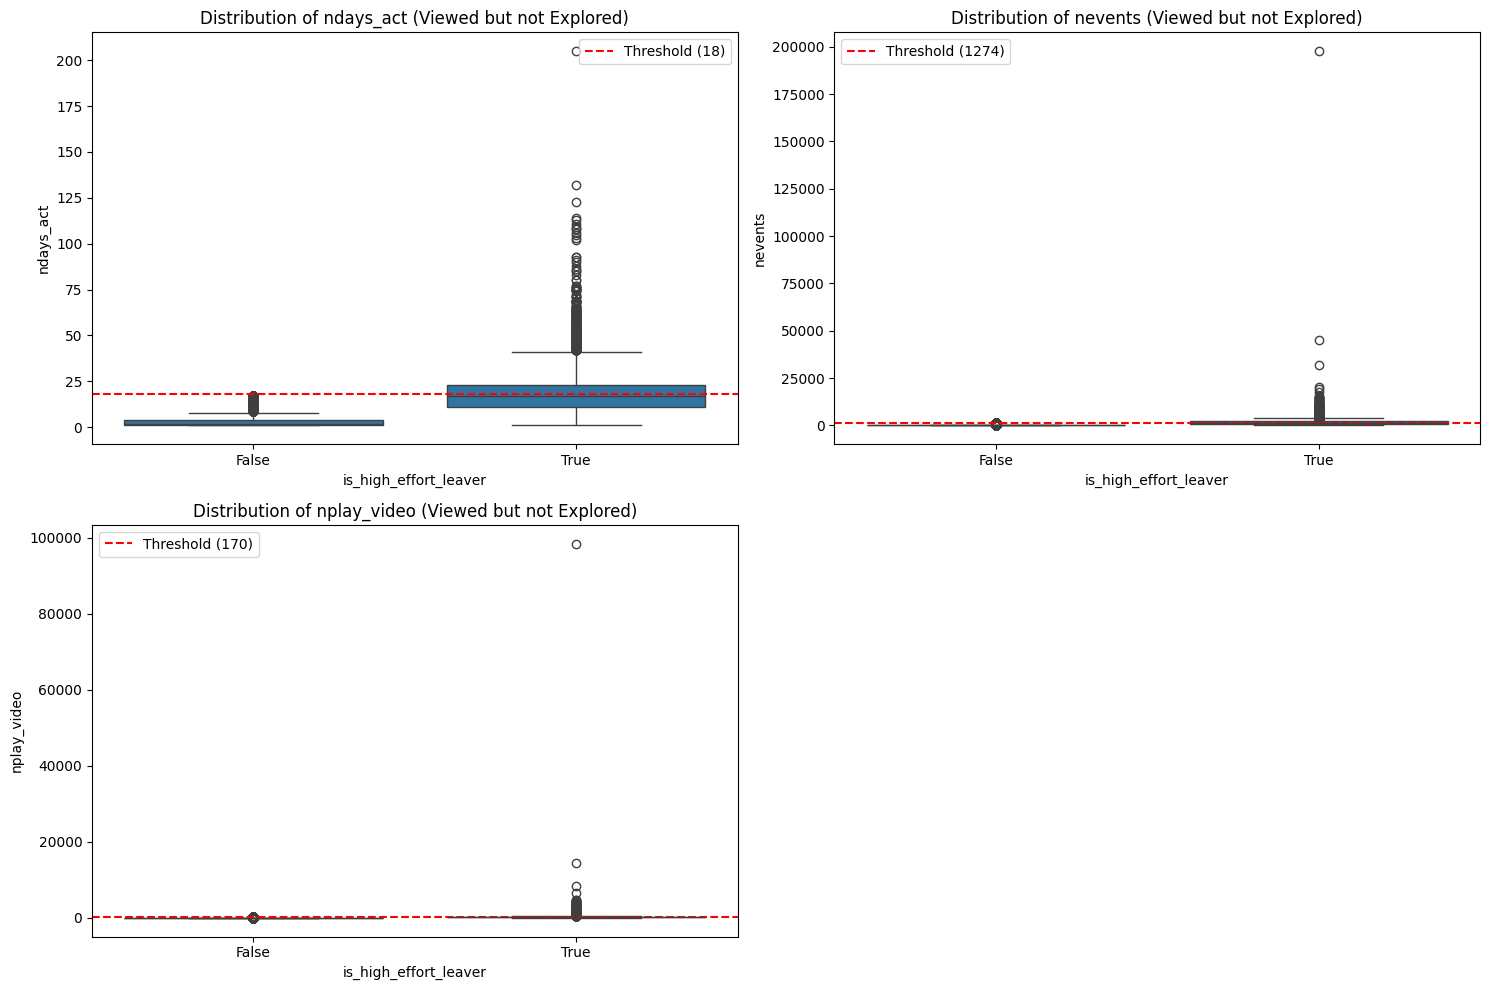

In [648]:
import matplotlib.pyplot as plt
import seaborn as sns

df = df.reset_index(drop=True)

# 임계값 설정
thresholds = {
    'ndays_act': 18,
    'nevents': 1274,
    'nplay_video': 170
}

# step 2 유저 그룹 분류 
# viewed는 했지만 explored는 못한 유저들 중, 설정한 기준을 하나라도 넘긴 '고관여 탐색 이탈자' 추출
target_condition = (df['viewed'] == 1) & (df['explored'] == 0)
df['is_high_effort_leaver'] = target_condition & ( 
    (df['ndays_act'] >= thresholds['ndays_act']) |
    (df['nevents'] >= thresholds['nevents']) |
    (df['nplay_video'] >= thresholds['nplay_video'])
)

# 임계값 기준 분포 확인
features = ['ndays_act', 'nevents', 'nplay_video']
plt.figure(figsize=(15, 10))

for i, col in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='is_high_effort_leaver', y=col, data=df[target_condition])
    plt.axhline(thresholds[col], color='red', linestyle='--', label=f'Threshold ({thresholds[col]})')
    plt.title(f'Distribution of {col} (Viewed but not Explored)')
    plt.legend()

plt.tight_layout()
plt.show()

In [649]:
# 이탈자 유형 세분화
# Step 1. 진입 전 이탈
r_step1 = ((df['registered'] == 1) & (df['viewed'] == 0)).sum()

# Step 2. 탐색 중 이탈
# 2-1. 단순 탐색 후 이탈 (기준치 미달)
r_step2_1 = ((df['viewed'] == 1) & (df['explored'] == 0) & (df['is_high_effort_leaver'] == False)).sum()

# 2-2. 고관여 탐색 후 이탈 (기준치 초과)
r_step2_2 = ((df['viewed'] == 1) & (df['explored'] == 0) & (df['is_high_effort_leaver'] == True)).sum()

print(f"진입 전 이탈 : {r_step1:,}명")
print(f"단순 탐색 후 이탈 : {r_step2_1:,}명")
print(f"고관여 탐색 후 이탈 : {r_step2_2:,}명")

진입 전 이탈 : 208,632명
단순 탐색 후 이탈 : 270,206명
고관여 탐색 후 이탈 : 17,571명


In [650]:
# Viewed -> Explored 단계 이탈자 중 고관여 탐색 유저의 비율
leaver_count = df[target_condition].shape[0]
high_effort_count = df['is_high_effort_leaver'].sum()
ratio = (high_effort_count / leaver_count) * 100

print(f"탐색 단계 이탈자 중 고관여 탐색 유저 비율: {ratio:.2f}%")

탐색 단계 이탈자 중 고관여 탐색 유저 비율: 6.11%


In [651]:
# 지표별 임계치 초과 여부 조합 분석
# 각 지표별 임계치 달성 여부 컬럼 생성
high_effort_leavers = df[df['is_high_effort_leaver'] == True].copy()

high_effort_leavers['met_days'] = high_effort_leavers['ndays_act'] >= thresholds['ndays_act']
high_effort_leavers['met_events'] = high_effort_leavers['nevents'] >= thresholds['nevents']
high_effort_leavers['met_video'] = high_effort_leavers['nplay_video'] >= thresholds['nplay_video']

# 어떤 조합이 가장 많은지 카운트
combination_counts = high_effort_leavers.groupby(['met_days', 'met_events', 'met_video']).size().reset_index(name='user_count')
print(combination_counts.sort_values(by='user_count', ascending=False))

   met_days  met_events  met_video  user_count
6      True        True       True        3603
0     False       False       True        3522
2     False        True       True        3086
3      True       False      False        3052
1     False        True      False        2391
5      True        True      False        1438
4      True       False       True         479


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_22304\2815693500.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_data, x='user_count', y='combination', palette='viridis')


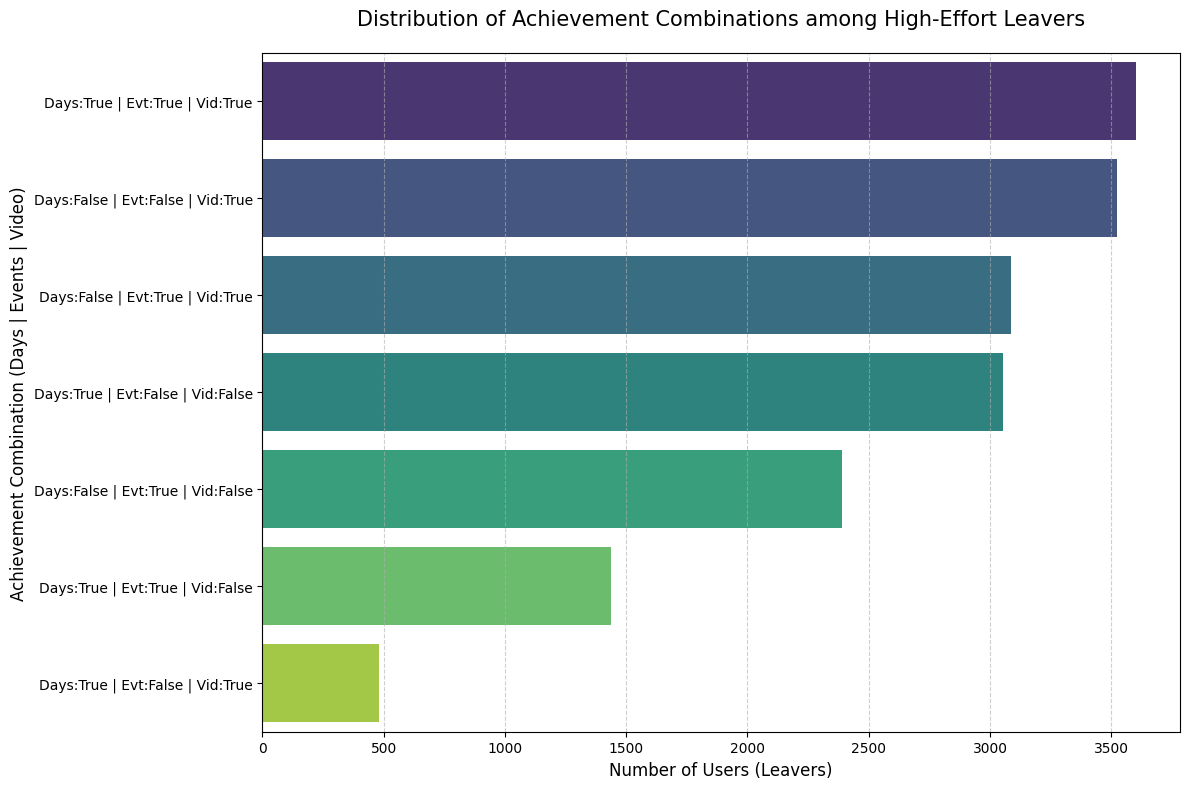

In [652]:
import matplotlib.pyplot as plt
import seaborn as sns

# 시각화를 위해 'True/False' 조합을 읽기 쉬운 텍스트로 변환
combination_counts['combination'] = (
    'Days:' + combination_counts['met_days'].astype(str) + 
    ' | Evt:' + combination_counts['met_events'].astype(str) + 
    ' | Vid:' + combination_counts['met_video'].astype(str)
)

# 내림차순 정렬 
plot_data = combination_counts.sort_values(by='user_count', ascending=False)

# 시각화
plt.figure(figsize=(12, 8))
sns.barplot(data=plot_data, x='user_count', y='combination', palette='viridis')

plt.title('Distribution of Achievement Combinations among High-Effort Leavers', fontsize=15, pad=20)
plt.xlabel('Number of Users (Leavers)', fontsize=12)
plt.ylabel('Achievement Combination (Days | Events | Video)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [653]:
import numpy as np
from scipy import stats

# 카이제곱 검정 
observed_values = combination_counts['user_count'].values
chi2_stat, p_val = stats.chisquare(observed_values)

# 효과 크기(Cramer's V) 
# 적합도 검정에서 Cramer's V = sqrt(chi2 / (n * (k - 1)))
n = np.sum(observed_values) # 전체 유저 수
k = len(observed_values)    # 조합의 개수 (8개)
cramer_v = np.sqrt(chi2_stat / (n * (k - 1)))

print(f"카이제곱 통계량: {chi2_stat:.4f}")
print(f"p-value: {p_val:.4e}")
print(f"효과 크기 (Cramer's V): {cramer_v:.4f}")

# 효과 크기 해석 가이드
if cramer_v < 0.1:
    res = "효과 없음 (Small)"
elif cramer_v < 0.3:
    res = "중간 정도의 효과 (Medium)"
else:
    res = "강한 효과 (Large)"
print(f"해석: {res}")

카이제곱 통계량: 3239.9108
p-value: 0.0000e+00
효과 크기 (Cramer's V): 0.1753
해석: 중간 정도의 효과 (Medium)


In [654]:
# 표준화 잔차(Standardized Residuals) 계산
# (관측값 - 기대값) / sqrt(기대값)
expected_values = np.mean(observed_values) # 모든 칸이 균등하다고 가정할 때의 기대값
residuals = (observed_values - expected_values) / np.sqrt(expected_values)

combination_counts['residuals'] = residuals
print(combination_counts[['combination', 'user_count', 'residuals']].sort_values(by='residuals', ascending=False))

                         combination  user_count  residuals
6    Days:True | Evt:True | Vid:True        3603  21.812939
0  Days:False | Evt:False | Vid:True        3522  20.196215
2   Days:False | Evt:True | Vid:True        3086  11.493850
3  Days:True | Evt:False | Vid:False        3052  10.815226
1  Days:False | Evt:True | Vid:False        2391  -2.378038
5   Days:True | Evt:True | Vid:False        1438 -21.399491
4   Days:True | Evt:False | Vid:True         479 -40.540701


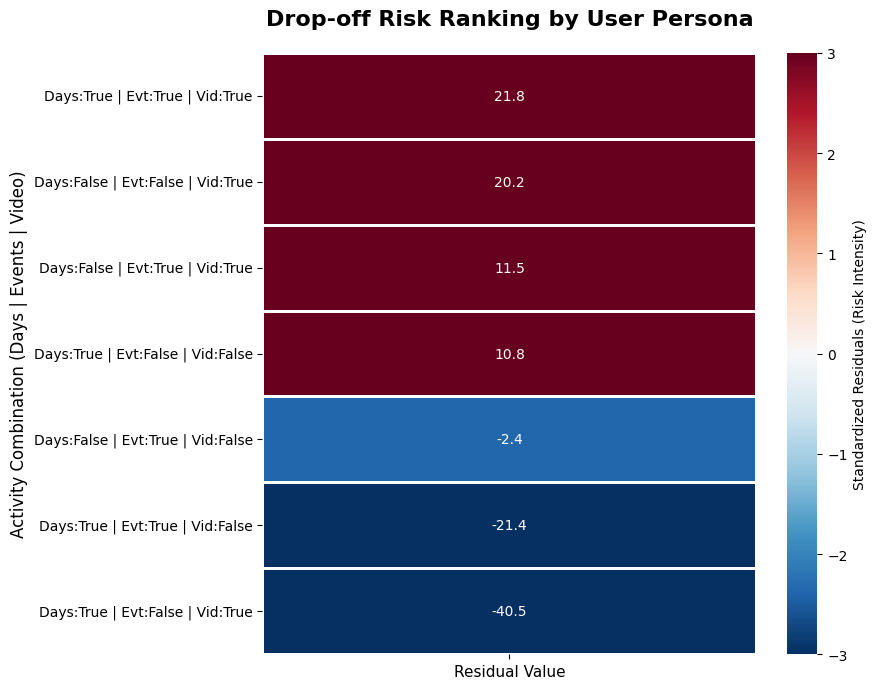

In [655]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 잔차 기준 내림차순 정렬
heatmap_data_sorted = combination_counts.sort_values(by='residuals', ascending=False)
heatmap_data_sorted = heatmap_data_sorted.set_index('combination')[['residuals']]

# 히트맵 시각화 
plt.figure(figsize=(9, 7)) 

# vmin, vmax를 +-3 정도로 설정하면 All True의 21.8이 아주 진하게 표시되어 강조 효과가 커집니다.
ax = sns.heatmap(heatmap_data_sorted, 
                 cmap='RdBu_r', 
                 annot=True, 
                 fmt=".1f", 
                 linewidths=1, 
                 cbar_kws={'label': 'Standardized Residuals (Risk Intensity)'},
                 vmin=-3, 
                 vmax=3)

plt.title('Drop-off Risk Ranking by User Persona', fontsize=16, pad=20, fontweight='bold')
plt.ylabel('Activity Combination (Days | Events | Video)', fontsize=12)
plt.xlabel('') 

# y축 라벨(조합명)을 가로로 정렬하여 읽기 편하게 설정
plt.yticks(rotation=0)
# x축 라벨 위치 및 텍스트 설정
ax.set_xticklabels(['Residual Value'], fontsize=11)

plt.tight_layout()
plt.show()

- 고관여 이탈자의 유형 탐색 결과, 모든 임계치를 넘긴 우수 유저가 가장 많이 이탈함 
- 이들은 서비스의 기능을 충분히 활용했음에도 불구하고 explored로 전환되지 못함 이는 원하는 정보를 못 찾았거나, 마지막 허들이 높았을 것으로 보임
- 영상 재생만 충족한 유저가 두번째로 많이 이탈함 이는 콘텐츠의 흥미도는 높으나 서비스 참여 유도가 부족함을 의미함
- 꾸준히 오지는 않았지만 하루 이틀만에 기준치를 초과한 벼락치기 유저들이 세번째로 많이 이탈함 이는 단기 집중도는 높으나 지속성이 약해 이탈한 것으로 보임

- 잔차 분석 결과, 모든 임계치를 넘긴 우수 유저의 이탈이 많이 이루어지는 것으로 보아 가장 열심히 참여한 유저가 역설적으로 가장 많이 이탈하는 시스템적 병목 현상이 강력 의심되며, 영상 몰입형 유저의 경우 다른 활동으로 확장되지 못하는 수동적 이탈 패턴을 보임

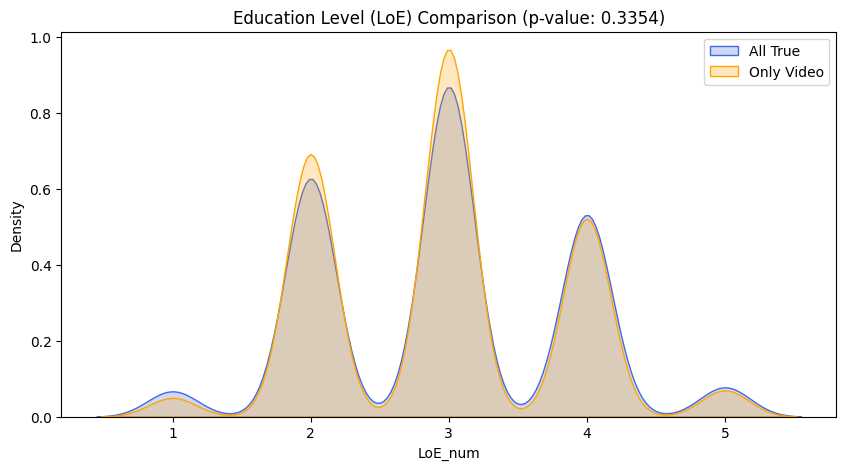

[Education Level (LoE)] All True 평균: 2.97 | Only Video 평균: 2.94
T-test 결과 p-value: 3.3544e-01
결과: 두 집단 간 Education Level (LoE) 차이가 유의미하지 않습니다.



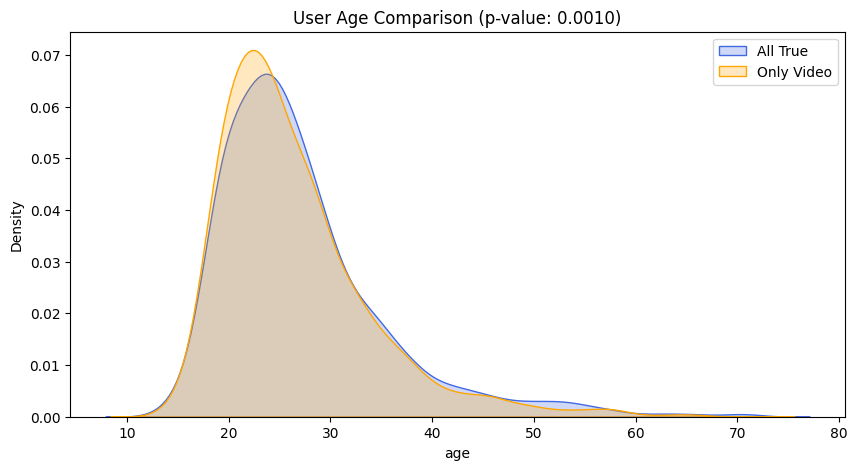

[User Age] All True 평균: 27.18 | Only Video 평균: 26.48
T-test 결과 p-value: 9.8470e-04
결과: 두 집단 간 User Age 차이가 통계적으로 유의미합니다.



In [656]:
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# 세 가지 핵심 그룹 정의 함수
def categorize_group(row):
    if row['met_days'] and row['met_events'] and row['met_video']:
        return 'All True (완벽형)'
    elif row['met_video'] and not row['met_days'] and not row['met_events']:
        return 'Only Video (시청형)'
    elif not row['met_days'] and (row['met_events'] or row['met_video']):
        return '벼락치기 (단기집중형)'
    return 'Other'

# 그룹 컬럼 생성 및 분석용 DF 추출 
high_effort_leavers['group'] = high_effort_leavers.apply(categorize_group, axis=1)
analysis_df = high_effort_leavers[high_effort_leavers['group'] != 'Other'].copy()

# 대상 그룹 추출 (All True vs Only Video)
group_A = analysis_df[analysis_df['group'] == 'All True (완벽형)']
group_B = analysis_df[analysis_df['group'] == 'Only Video (시청형)']

# 비교 분석 함수 (T-test 포함)
def compare_groups(col_name, title):
    # 결측치 제거
    data_A = group_A[col_name].dropna()
    data_B = group_B[col_name].dropna()
    
    # T-test 수행
    t_stat, p_val = stats.ttest_ind(data_A, data_B)
    
    # 시각화
    plt.figure(figsize=(10, 5))
    sns.kdeplot(data_A, label='All True', fill=True, color='royalblue')
    sns.kdeplot(data_B, label='Only Video', fill=True, color='orange')
    
    plt.title(f'{title} Comparison (p-value: {p_val:.4f})')
    plt.legend()
    plt.show()
    
    print(f"[{title}] All True 평균: {data_A.mean():.2f} | Only Video 평균: {data_B.mean():.2f}")
    print(f"T-test 결과 p-value: {p_val:.4e}")
    if p_val < 0.05:
        print(f"결과: 두 집단 간 {title} 차이가 통계적으로 유의미합니다.\n")
    else:
        print(f"결과: 두 집단 간 {title} 차이가 유의미하지 않습니다.\n")

# 학력(LoE_num)과 나이(age) 비교 실행
compare_groups('LoE_num', 'Education Level (LoE)')
compare_groups('age', 'User Age')

In [657]:
import numpy as np

# 1. 두 집단의 나이 데이터 추출 (결측치 제거)
age_A = group_A['age'].dropna()
age_B = group_B['age'].dropna()

# 2. Cohen's d 계산 함수
def cohen_d(x, y):
    nx, ny = len(x), len(y)
    dof = nx + ny - 2
    # 합산 표준편차(Pooled Standard Deviation) 계산
    pooled_std = np.sqrt(((nx-1)*np.std(x, ddof=1)**2 + (ny-1)*np.std(y, ddof=1)**2) / dof)
    return (np.mean(x) - np.mean(y)) / pooled_std

d_val = cohen_d(age_A, age_B)

print(f"나이 차이에 대한 Cohen's d: {d_val:.4f}")

# 3. 효과 크기 해석
if abs(d_val) < 0.2:
    res = "효과 작음 (Negligible)"
elif abs(d_val) < 0.5:
    res = "중간 정도 (Small/Medium)"
else:
    res = "효과 큼 (Large)"
print(f"해석: {res}")

나이 차이에 대한 Cohen's d: 0.0874
해석: 효과 작음 (Negligible)


- 두 집단 모두 평균 2.9 ~ 3.0 정도로 비슷한 교육 배경을 가짐
- 두 집단 간 연령 차이는 통계적으로 유의미하였으나 효과 크기가 0.087로 매우 작음 
- 따라서 이탈은 유저의 인구통계학적 특성 때문이 아니라 서비스 내에서 겪는 경험에 의해 결정됨을 확인함

[활동 밀도 분석 결과]
All True 밀도 평균: 50.90 | Only Video 밀도 평균: 44.63
p-value: 9.5680e-02
Cohen's d: 0.0395


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_22304\1580579918.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=analysis_df[analysis_df['group'].isin(['All True (완벽형)', 'Only Video (시청형)'])],
c:\Users\김규리\project_3\data-analysis-practical-project\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50756 (\N{HANGUL SYLLABLE WAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\김규리\project_3\data-analysis-practical-project\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48317 (\N{HANGUL SYLLABLE BYEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\김규리\project_3\data-analysis-practical-project\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE H

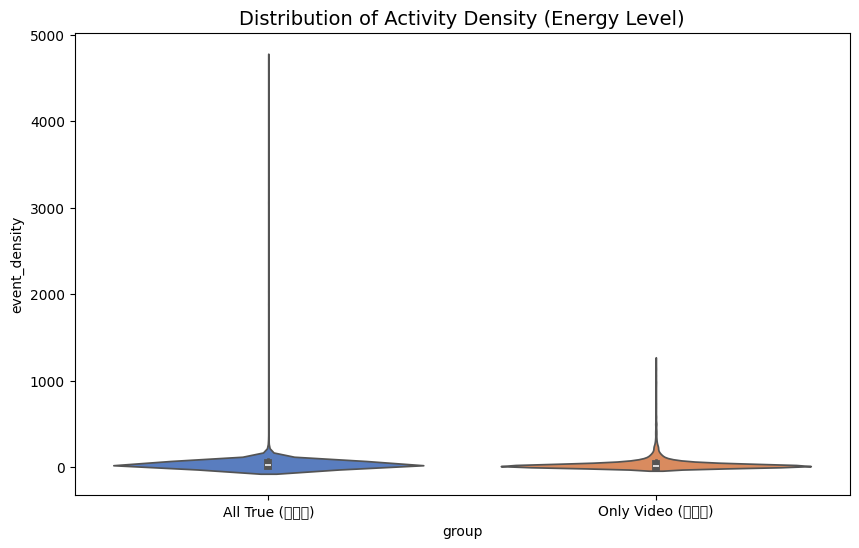

In [658]:
# 활동 밀도
analysis_df['event_density'] = analysis_df['nevents'] / (analysis_df['duration'] + 1)

group_A = analysis_df[analysis_df['group'] == 'All True (완벽형)']
group_B = analysis_df[analysis_df['group'] == 'Only Video (시청형)']

# 활동 밀도 Cohen's d 계산
dens_A = group_A['event_density'].dropna()
dens_B = group_B['event_density'].dropna()

t_stat_dens, p_val_dens = stats.ttest_ind(dens_A, dens_B)
d_dens = (np.mean(dens_A) - np.mean(dens_B)) / np.sqrt(((len(dens_A)-1)*np.std(dens_A, ddof=1)**2 + (len(dens_B)-1)*np.std(dens_B, ddof=1)**2) / (len(dens_A)+len(dens_B)-2))

print(f"[활동 밀도 분석 결과]")
print(f"All True 밀도 평균: {dens_A.mean():.2f} | Only Video 밀도 평균: {dens_B.mean():.2f}")
print(f"p-value: {p_val_dens:.4e}")
print(f"Cohen's d: {d_dens:.4f}")

# 시각화 
plt.figure(figsize=(10, 6))
sns.violinplot(data=analysis_df[analysis_df['group'].isin(['All True (완벽형)', 'Only Video (시청형)'])], 
               x='group', y='event_density', palette='muted')
plt.title('Distribution of Activity Density (Energy Level)', fontsize=14)
plt.show()

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_22304\2677415620.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=filtered_df[filtered_df['group'].isin(['All True (완벽형)', 'Only Video (시청형)'])],
c:\Users\김규리\project_3\data-analysis-practical-project\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50756 (\N{HANGUL SYLLABLE WAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\김규리\project_3\data-analysis-practical-project\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48317 (\N{HANGUL SYLLABLE BYEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\김규리\project_3\data-analysis-practical-project\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HY

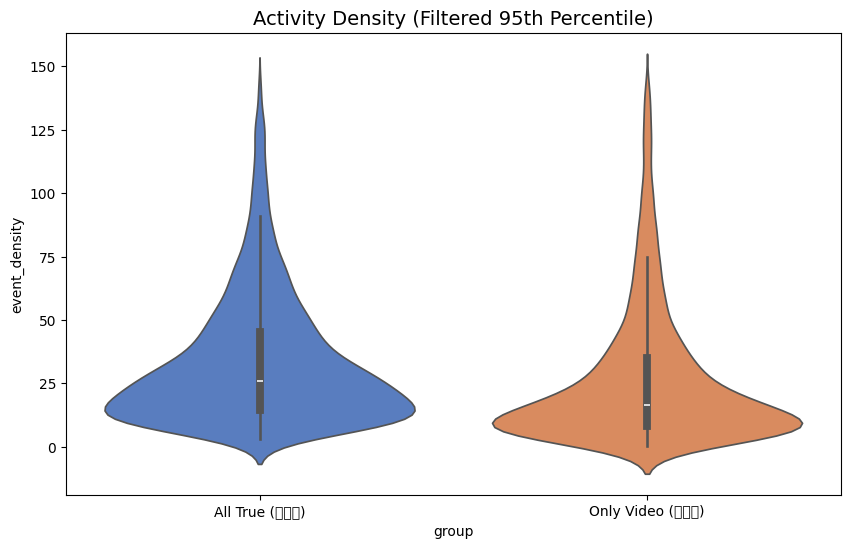

이상치 제거 기준값: 144.38


In [659]:
# 상위 5% 이상치 제거 
limit = analysis_df['event_density'].quantile(0.95)
filtered_df = analysis_df[analysis_df['event_density'] <= limit]

# 시각화 재실행
plt.figure(figsize=(10, 6))
sns.violinplot(data=filtered_df[filtered_df['group'].isin(['All True (완벽형)', 'Only Video (시청형)'])], 
               x='group', y='event_density', palette='muted')
plt.title('Activity Density (Filtered 95th Percentile)', fontsize=14)
plt.show()

print(f"이상치 제거 기준값: {limit:.2f}")

In [660]:
from scipy import stats

# 필터링된 데이터에서 두 그룹 추출 (95% 유저 기준)
dens_A_filtered = filtered_df[filtered_df['group'] == 'All True (완벽형)']['event_density'].dropna()
dens_B_filtered = filtered_df[filtered_df['group'] == 'Only Video (시청형)']['event_density'].dropna()

# Mann-Whitney U Test 수행
u_stat, p_val_u = stats.mannwhitneyu(dens_A_filtered, dens_B_filtered, alternative='two-sided')

# 결과 출력
print(f"[Mann-Whitney U Test 결과]")
print(f"All True 중앙값: {dens_A_filtered.median():.2f}")
print(f"Only Video 중앙값: {dens_B_filtered.median():.2f}")
print(f"U 통계량: {u_stat:.2f}")
print(f"p-value: {p_val_u:.4e}")

if p_val_u < 0.05:
    print("결과: 두 집단의 중앙값 차이가 통계적으로 매우 유의미합니다.")
else:
    print("결과: 두 집단의 중앙값 차이가 유의미하지 않습니다.")

[Mann-Whitney U Test 결과]
All True 중앙값: 26.04
Only Video 중앙값: 16.56
U 통계량: 7385329.00
p-value: 5.8435e-75
결과: 두 집단의 중앙값 차이가 통계적으로 매우 유의미합니다.


- 이상치 제거 후에도 발생할 수 있는 데이터 왜곡을 방지하고자 비모수 검정을 실시한 결과, 두 집단의 활동 밀도 중앙값은 통계적으로 매우 유의미한 차이를 보임
- 이는 모든 임계치를 넘긴 우수 유저가 영상 몰입형 유저보다 중앙값 기준 약 1.6배 더 더 높은 에너지를 쏟고 있음
- 모든 임계치를 넘긴 우수 유저는 이탈 직전까지 고밀도 활동을 하였으나 이탈한 것으로 보아 영상 몰입형 유저보다 체계적으로 더 높은 서비스 피로도를 겪고 있음을 시사함

=> 모든 임계치를 넘긴 우수 이탈 유저 (높은 피로도와 정체 구간): 활동 밀도 급증 시 정보 제공 챗봇 팝업 및 심화 가이드 제공

=> 영상 몰입형 이탈 유저 (낮은 상호 작용과 몰입) : 영상 시청 중 퀴즈 배치 등 활동 기반 리워드 제공 등 활동성 강화

- 향후 검증 방안 : 이탈 잔차가 가장 높은 상위 3개 강의에 우선적으로 챗봇 팝업 기능을 도입하여 A/B 테스트 실시
- 목표 지표 : 활동 밀도가 적정 수준으로 안정화되면서 explored 전환율이 상승하는지 추적

In [661]:
# !pip install statsmodels

In [662]:
# import statsmodels.api as sm

# # 서로 독립적인 핵심 변수만 선택 (상관관계가 높은 원천 데이터 제외)
# features = ['age','event_density'] 

# # 데이터 정제 (무한대/결측치 제거 및 인덱스 동기화)
# X_final = filtered_df[features].replace([np.inf, -np.inf], np.nan).dropna()
# y_final = filtered_df.loc[X_final.index, 'is_high_effort_leaver'].astype(int)

# # 상수항 추가 및 로지스틱 회귀 실행
# X_final = sm.add_constant(X_final)
# model = sm.Logit(y_final, X_final).fit()

# # 결과 확인
# print(model.summary())
# print("\n[변수별 영향력(Odds Ratio)]")
# print(np.exp(model.params))

============================================================================

===========================================================================

In [663]:
# import numpy as np
# from scipy import stats

# # 고관여 탐색 이탈자들의 상당수가 많은 활동량에도 불구하고 9챕터 이상의 진도를 나가지 못하는 학습 정체 현상을 보임
# # 탐색 단계 이탈자 중 활동이 아예 없는 유저는 효율성(nchapters/nevents) 계산 자체가 무의미하므로 제외
# active_user = df[(df['nevents'] > 0) & (df['nevents'].notna()) & (df['nchapters'] > 0) & (df['nchapters'].notna()) & (df['viewed'] == 1) & (df['explored'] == 0)].copy()

# # 효율성 지표 
# active_user['learning_efficiency'] = active_user['nchapters'] / active_user['nevents']

# # 그룹 나누기
# group_high = active_user[active_user['is_high_effort_leaver'] == True]['learning_efficiency']
# group_low = active_user[active_user['is_high_effort_leaver'] == False]['learning_efficiency']

# # 통계 검정 (Mann-Whitney U)
# u_stat, p_val = stats.mannwhitneyu(group_low, group_high, alternative='two-sided')

# print(f"고관여 탐색 이탈자 효율성 평균: {group_high.mean():.4f}")
# print(f"단순 탐색 이탈자 효율성 평균: {group_low.mean():.4f}")
# print(f"P-value: {p_val:.10f}")
# print()
# if p_val < 0.05:
#     ratio = group_low.mean() / group_high.mean()
#     print(f"결과 : 학습 정체 현상이 통계적으로 매우 유의미하게 확인")
#     print(f"효율성 분석 : 고관여 탐색 이탈자의 학습 효율은 단순 탐색 이탈자 대비 {1/ratio:.1%} 수준에 불과")
#     print(f"결론 : 고관여 탐색 유저들은 동일 진도 달성을 위해 단순 탐색 유저들 보다 노력 대비 효율이 약 {ratio:.1f}배 낮음")

In [664]:
# # 효과 크기(Effect Size) 계산 및 해석
# n1 = len(group_low)
# n2 = len(group_high)

# # Mann-Whitney U 검정용 효과 크기 공식 (Rank-Biserial Correlation / Cliff's Delta)
# effect_size = abs(1 - (2 * u_stat) / (n1 * n2))

# print("-" * 50)
# print(f"▶ 효과 크기 (r): {effect_size:.4f}")

# # 효과 크기 해석 가이드라인 (Cohen's 기준 변형)
# if effect_size >= 0.5:
#     magnitude = "매우 큼 (Large)"
#     biz_impact = "압도적인 차이입니다. 단순한 우연이 아니라 앱의 구조적인 병목(문제)이 확실합니다."
# elif effect_size >= 0.3:
#     magnitude = "중간 (Medium)"
#     biz_impact = "유의미한 차이입니다. 두 그룹의 행동 패턴이 확연히 갈립니다."
# elif effect_size >= 0.1:
#     magnitude = "작음 (Small)"
#     biz_impact = "통계적으로는 차이가 있으나, 실질적인 체감 차이는 크지 않을 수 있습니다."
# else:
#     magnitude = "거의 없음 (Negligible)"
#     biz_impact = "데이터가 많아서 p-value만 낮게 나왔을 뿐, 실질적인 차이는 없습니다."

# print(f"▶ 해석: {magnitude} - {biz_impact}")

- 고관여 탐색 이탈자들은 학습 의지가 부족한 것이 아닌, 특정 구간에서 무의미한 반복(이해되지 않은 강의 반복 시청 등)행동을 하고 있을 가능성이 큼
- 이는 단순한 활동을 독려하는 것 보다 노력 대비 성과가 나지 않는 특정 학습 장벽을 제거하는 것이 유지율 개선의 핵심으로 보임

In [665]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# # 실제 활동이 있는 탐색 중 이탈 유저
# explored_leaver = df[
#     (df['viewed'] == 1) & 
#     (df['explored'] == 0) & 
#     (df['nevents'] > 0) &
#     (df['nevents']).notna() &
#     (df['nplay_video'] > 0) &
#     (df['nplay_video']).notna()
# ].copy()

# # 지표 계산
# # 일평균 활동 밀도
# explored_leaver['daily_intensity'] = explored_leaver['nevents'] / explored_leaver['ndays_act'].replace(0, 1)

# # 노력 대비 비디오 시청 비중
# explored_leaver['video_ratio'] = explored_leaver['nplay_video'] / explored_leaver['nevents']

# # 시각화
# fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# # [왼쪽] 일평균 활동 밀도
# sns.boxplot(x='is_high_effort_leaver', y='daily_intensity', data=explored_leaver, ax=axes[0], palette='Set2')
# axes[0].set_title('Daily Activity Intensity (Events per Day)')
# axes[0].set_yscale('log')
# axes[0].set_ylabel('Log(Events per Day)')

# # [오른쪽] 노력 대비 비디오 시청 비중
# sns.barplot(x='is_high_effort_leaver', y='video_ratio', data=explored_leaver, ax=axes[1], palette='Set2')
# axes[1].set_title('Video Play Ratio in Total Events')
# axes[1].set_ylabel('Video Events / Total Events')

# plt.tight_layout()
# plt.show()

# # 통계 요약
# summary = explored_leaver.groupby('is_high_effort_leaver')[['daily_intensity', 'video_ratio']].median()
# print("===== 학습 활동 밀도 요약 (Median) =====")
# print(summary)

In [666]:
# from scipy import stats

# # 실제 활동이 있는 탐색 중 이탈 유저
# group_high1 = explored_leaver[explored_leaver['is_high_effort_leaver'] == True]['daily_intensity']
# group_low1 = explored_leaver[explored_leaver['is_high_effort_leaver'] == False]['daily_intensity']

# # Mann-Whitney U Test 실행
# u_stat, p_value = stats.mannwhitneyu(group_high1, group_low1, alternative='greater')

# # 결과 출력 및 해석
# print(f"===== 통계적 검정 결과 (Mann-Whitney U Test) =====")
# print(f"U-statistic: {u_stat:.2f}")
# print(f"P-value: {p_value:.10f}")

# if p_value < 0.05:
#     print(f"\n[결론] 두 집단의 활동 밀도 차이는 통계적으로 유의미한 차이가 있음")
#     print(f"고관여 탐색 이탈자의 활동 밀도는 단순 탐색 이탈자보다 '우연히' 높을 확률이 거의 없음")
# else:
#     print(f"\n[결론] 두 그룹 간 유의미한 차이가 발견되지 않음")

In [667]:
# from scipy import stats

# # 데이터 준비 
# v_group_high = explored_leaver[explored_leaver['is_high_effort_leaver'] == True]['video_ratio']
# v_group_low = explored_leaver[explored_leaver['is_high_effort_leaver'] == False]['video_ratio']

# # Mann-Whitney U Test 실행
# u_stat_v, p_value_v = stats.mannwhitneyu(v_group_high, v_group_low, alternative='two-sided')

# print(f"===== 비디오 시청 비중(video_ratio) 검정 결과 =====")
# print(f"U-statistic: {u_stat_v:.2f}")
# print(f"P-value: {p_value_v:.10f}")

# if p_value_v < 0.05:
#     print("\n[결론] 두 집단의 비디오 시청 비중은 통계적으로 유의미한 차이가 있음")
# else:
#     print("\n[결론] 두 집단의 비디오 시청 비중은 통계적으로 유의미한 차이가 없음")
#     print("즉, 두 집단은 동일한 '학습 방식'을 가졌으나 활동 강도에서만 차이가 남")

In [668]:
# import numpy as np
# from scipy import stats

# def calculate_effect_size(group1, group2, u_stat):
#     n1 = len(group1)
#     n2 = len(group2)
#     # Rank-Biserial Correlation (r) 계산
#     r = 1 - (2 * u_stat / (n1 * n2))
#     return abs(r)

# def interpret_r(r_value):
#     if r_value >= 0.5: return "Large (매우 큰 차이)"
#     elif r_value >= 0.3: return "Medium (중간 차이)"
#     elif r_value >= 0.1: return "Small (작은 차이)"
#     else: return "Negligible (무시할만한 차이)"

# # 1. 활동 밀도(Intensity) 효과 크기
# u_stat_i, p_i = stats.mannwhitneyu(group_high1, group_low1, alternative='greater')
# r_intensity = calculate_effect_size(group_high1, group_low1, u_stat_i)

# # 2. 비디오 비중(Video Ratio) 효과 크기
# u_stat_v, p_v = stats.mannwhitneyu(v_group_high, v_group_low, alternative='two-sided')
# r_video = calculate_effect_size(v_group_high, v_group_low, u_stat_v)

# print("결과 [1] 활동 밀도 (Daily Intensity)")
# print(f"- P-value: {p_i:.10f} / Effect Size(r): {r_intensity:.4f} ({interpret_r(r_intensity)})")

# print("\n결과 [2] 비디오 시청 비중 (Video Ratio)")
# print(f"- P-value: {p_v:.10f} / Effect Size(r): {r_video:.4f} ({interpret_r(r_video)})")

- 고관여 탐색 이탈자와 단순 탐색 이탈자의 비디오 시청 비중이 비슷하며 이들의 모범적인 학습 경로를 따름
- 고관여 탐색 이탈자의 활동 밀도는 고관여 이탈자가 훨씬 의지가 매우 강한 핵심 타겟임
- 그럼에도 고관여 탐색 유저의 효율은 20.4배 낮으며, 특정 구간(9챕터)의 시스템적 정체가 고관여 탐색 유저들의 이탈을 갉아먹고 있음

=> 고관여 탐색 이탈자는 일반 학습자와 동일한 학습 스타일을 유지하면서도 5.5배 높은 학습 밀도로 임해왔으나, 고관여 탐색 이탈자들의 학습 효율은 단순 탐색 이탈자의 4.9% 수준에 불과함, 효과 크기가 입증하듯(r=0.9)가 입증하듯, 이는 학습자 개별 특성이 아닌 플랫폼 내부의 구조적 병목에 의한 강제적 정체임이 확실함, 이는 1.6만 명의 잠재적 수료자를 구제하기 위한 시스템 전수 조사가 시급함

In [669]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd

# if 'course_id' not in df.columns:
#     df = df.reset_index() 

# # 실제 활동이 있는 탐색 중 이탈 유저
# plot_df = df[(df['viewed'] == 1) & (df['explored'] == 0) & (df['nevents'] > 0) & (df['nevents']).notna() & (df['nchapters'] > 0) & (df['nchapters']).notna()].copy()

# # 강의별 최대 챕터 수 계산 및 결합
# course_max = df.groupby('course_id')['nchapters'].max().reset_index()
# course_max.columns = ['course_id', 'total_chapters']
# plot_df = plot_df.merge(course_max, on='course_id', how='left')

# # 상대적 진도율(%) 계산 
# plot_df['progress_rate'] = (plot_df['nchapters'] / plot_df['total_chapters'].replace(0, 1)) * 100
# plot_df['progress_rate'] = plot_df['progress_rate'].clip(0, 100)

# # 5. 시각화
# plt.figure(figsize=(14, 8))

# # 스캐터 플롯
# sns.scatterplot(
#     x='nevents', 
#     y='progress_rate', 
#     hue='is_high_effort_leaver', 
#     data=plot_df,
#     palette={True: '#e74c3c', False: '#3498db'}, 
#     alpha=0.5,
#     s=60
# )

# # 그룹별 추세선 (노력 대비 성과의 기울기 차이)
# sns.regplot(x='nevents', y='progress_rate', data=plot_df[plot_df['is_high_effort_leaver']==False], scatter=False, color="#035E9B", label='Simple Leaver Trend')
# sns.regplot(x='nevents', y='progress_rate', data=plot_df[plot_df['is_high_effort_leaver']==True], scatter=False, color="#f11c04", label='High-Effort Leaver Trend')

# plt.title('The Gap: Effort vs. Progress Rate (%)', fontsize=15, fontweight='bold')
# plt.xlabel('Total Effort (nevents)', fontsize=12)
# plt.ylabel('Progress Rate (%)', fontsize=12)
# plt.legend(title='High Effort Group')
# plt.grid(True, linestyle='--', alpha=0.6)

# # x축 범위 제한
# plt.xlim(0, plot_df['nevents'].quantile(0.99)) 
# plt.ylim(0, 105)

# plt.tight_layout()
# plt.show()

- 활동량 임계점 전후의 진척도 변화율을 비교하여, 고관여 탐색 이탈자의 학습 정체 현상을 시각화하기 위해 두 개의 회귀선을 사용
- 고관여 탐색 이탈자는 활동량이 1,500에서 2,500으로 늘어나도 진척도는 여전히 30%대에 머물고 있음
- 고관여 탐색 이탈자에게 더 많은 활동을 유도하는 것보다 왜 30~40% 구간에서 벽에 부딪히는지를 파악하는 것이 우선임
- 고관여 탐색 이탈자는 일정 수준 이상의 노력을 투입해도 성과로 연결되지 않는 정체 구간(30%)이 존재함
- 단순 탐색 이탈자의 경우, 노력이 진척도로 비교적 정직하게 전환됨

In [670]:
# from scipy import stats

# # 데이터 분리: 각 그룹의 진도율 데이터 추출
# group_high2 = plot_df[plot_df['is_high_effort_leaver'] == True]['progress_rate']
# group_simple = plot_df[plot_df['is_high_effort_leaver'] == False]['progress_rate']

# # [검정] Mann-Whitney U Test (비모수 검정)
# u_stat, p_val_mw = stats.mannwhitneyu(group_high2, group_simple, alternative='two-sided')

# # 결과 출력
# print(f"--- 검정 결과 요약 ---")
# print(f"Group Median - High Effort: {group_high2.median():.2f}% vs Simple: {group_simple.median():.2f}%")
# print(f"Mann-Whitney U p-value: {p_val_mw:.4f}")

In [671]:
# n1 = len(group_high2)
# n2 = len(group_simple)
# # r = 1 - (2 * U) / (n1 * n2)
# r_rank_biserial = 1 - (2 * u_stat) / (n1 * n2)

# print(f"Effect Size (Rank-Biserial Correlation): {abs(r_rank_biserial):.4f}")

- 본 분석을 통해 활동량 임계점을 넘긴 고관여 탐색 이탈자는 단순히 활동만 많은 것이 아니라, 진척도 면에서도 단순 탐색 이탈자와 완전히 차별된 행동 양상을 보임
- 단순 탐색 이탈자 : 진도율 중앙값이 10.53%에 불과하다는 점은, 대다수의 이탈이 학습 극초반부에서 발생하고 있음을 시사함 이들은 활동량에 비례해 진도가 나가는 특성을 보이므로, 초기 이탈을 방지하기 위한 온보딩 강화나 첫 10% 구간의 흥미 유발 요소 배치가 시급함
- 고관여 탐색 이탈자 : 단기 탐색 이탈자 보다 진척도면에서 약 2.6배 높음 초기 장벽은 넘었으나 약 30% 지점의 병목 구간에서 무수한 활동만 반복하다 이탈하는 과몰입 정체형 집단

- 10% 구간 : 단순 탐색 이탈자를 위한 온보딩 및 첫 강의 몰입도 강화
- 28% 구간 : 고관여 탐색 이탈자가 겪고 있는 구체적인 장애물에 대한 정성적 로그 분석 추가 실시

In [672]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# # 상대적 진도율 구간 생성
# plot_df['progress_bin'] = pd.cut(plot_df['progress_rate'], bins=range(0, 110, 10), labels=[f'{i}%' for i in range(10, 110, 10)])

# # 이탈 지점 분포 시각화
# plt.figure(figsize=(12, 6))
# sns.countplot(x='progress_bin', hue='is_high_effort_leaver', data=plot_df, palette={True: '#e74c3c', False: '#3498db'})

# plt.title('Drop-off Points by Progress Rate Bucket', fontsize=14, fontweight='bold')
# plt.xlabel('Progress Rate Bucket (%)', fontsize=12)
# plt.ylabel('Number of Leavers', fontsize=12)
# plt.legend(title='High Effort Group')
# plt.grid(axis='y', linestyle='--', alpha=0.5)
# plt.show()

In [673]:
# # 강의 카테고리별(또는 난이도별) 그룹 비중 분석
# # 특정 과목군에서만 병목 현상이 발생하는지 확인하여 콘텐츠 개선의 우선순위를 정하기 위함
# category_analysis = plot_df.groupby('course_id')['is_high_effort_leaver'].mean().reset_index()
# category_analysis.columns = ['course_id', 'high_effort_ratio']

# # 상위 10개 위험 강의 시각화 
# top_risk_courses = category_analysis.sort_values(by='high_effort_ratio', ascending=False).head(10)

# plt.figure(figsize=(12, 6))
# sns.barplot(x='high_effort_ratio', y='course_id', data=top_risk_courses, palette='Reds_r')
# plt.title('Top 10 Courses with High-Effort Bottlenecks', fontsize=14, fontweight='bold')
# plt.xlabel('Ratio of High-Effort Leavers', fontsize=12)
# plt.ylabel('Course ID', fontsize=12)
# plt.show()

In [674]:
# # 강의별 기초 통계량 계산
# # 강의별 이탈률과 샘플 수를 한 번에 파악하여 보정 공식을 적용
# course_stats = plot_df.groupby('course_id')['is_high_effort_leaver'].agg(['mean', 'count']).reset_index()
# course_stats.columns = ['course_id', 'raw_ratio', 'user_count']

# # 베이지안 보정을 위한 파라미터 설정
# # C (전체 평균): 데이터가 전혀 없을 때 가정할 기본 이탈률
# # m (신뢰 임계치): 해당 강의의 데이터를 온전히 신뢰하기 위해 필요한 최소 유저 수 (보통 중앙값 사용)
# C = course_stats['raw_ratio'].mean()
# m = course_stats['user_count'].quantile(0.5) 

# # 베이지안 평균 계산 함수
# # v: 해당 강의 유저 수, R: 해당 강의 이탈률, C: 전체 평균, m: 가중치
# def get_bayesian_avg(v, R, C, m):
#     return (v / (v + m) * R) + (m / (v + m) * C)

# course_stats['adjusted_ratio'] = course_stats.apply(
#     lambda x: get_bayesian_avg(x['user_count'], x['raw_ratio'], C, m), axis=1
# )

# # 보정된 비율 기준 상위 10개 위험 강의 추출
# top_10_bottlenecks = course_stats.sort_values(by='adjusted_ratio', ascending=False).head(10)

In [675]:
# plt.figure(figsize=(14, 7))

# # 보정된 비율 시각화
# sns.barplot(x='adjusted_ratio', y='course_id', data=top_10_bottlenecks, palette='OrRd_r')

# plt.title(f'Top 10 Bottleneck Courses (Bayesian Adjusted, m={m:.1f})', fontsize=15, fontweight='bold')
# plt.xlabel('Adjusted High-Effort Leaver Ratio', fontsize=12)
# plt.ylabel('Course ID', fontsize=12)
# plt.axvline(C, color='blue', linestyle='--', label=f'Overall Avg ({C:.2%})')
# plt.legend()
# plt.grid(axis='x', linestyle='--', alpha=0.6)
# plt.show()

- 베이지안 보정을 통해 샘플 수 왜곡을 제거하고 실질적인 고관여 탐색 이탈자 유발 강의 도출

In [676]:
# # 베이지안 상위 10개 강의 ID 추출
# top_10_ids = top_10_bottlenecks['course_id'].tolist()

# # 해당 강의들의 데이터만 필터링
# top_10_df = plot_df[plot_df['course_id'].isin(top_10_ids)].copy()

# # 강의별 이탈 지점 시각화 
# plt.figure(figsize=(15, 8))

# # 강의별로 어느 진도율 구간에서 피크가 발생하는지 비교하기 위함
# for course in top_10_ids:
#     sns.kdeplot(
#         data=top_10_df[top_10_df['course_id'] == course], 
#         x='progress_rate', 
#         label=course,
#         fill=True,
#         alpha=0.1
#     )

# plt.title('Drop-off Point Distribution for Top 10 Bottleneck Courses', fontsize=15, fontweight='bold')
# plt.xlabel('Progress Rate (%)', fontsize=12)
# plt.ylabel('Density of Leavers', fontsize=12)
# plt.xlim(0, 100)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.grid(axis='y', linestyle='--', alpha=0.5)
# plt.tight_layout()
# plt.show()

- 분석 대상 강의들에서 이탈 밀도가 상대적 진도율 10~15% 구간에서 비정상적으로 높은 것으로 보아 구조적 병목 현상에 갇혀 있음을 증명 이는 강의의 난이도 곡선이 초반에 너무 가파르거나 진입 장벽이 매우 높음을 의미하기에 단순히 활동 유도를 늘리는 마케팅보다는 초기 고난도 구간의 학습 허들을 낮추는 콘텐츠 최적화가 이탈률 개선의 핵심임

In [677]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd
# # 학력별 단순 탐색 / 고관여 탐색 이탈자 수 비교
# leavers_df = df[(df['viewed'] == 1) & (df['explored'] == 0)].copy()

# plt.figure(figsize=(14, 7))
# ax = sns.countplot(x='LoE_DI', hue='is_high_effort_leaver', data=leavers_df, 
#                    order=leavers_df['LoE_DI'].value_counts().index, palette='viridis')

# # 막대 그래프 위에 실제 인원수 표시
# for p in ax.patches:
#     height = p.get_height()
#     if height > 0: 
#         ax.text(p.get_x() + p.get_width()/2., height + 100, 
#                 f'{int(height):,}',
#                 ha="center", fontsize=10, fontweight='bold')

# plt.title('Leaver Type by Education Level (Actual Count)', fontsize=15)
# plt.xlabel('Level of Education')
# plt.ylabel('Number of Users')
# plt.legend(title='High Effort Leaver', labels=['False (Low)', 'True (High)'])
# plt.xticks(rotation=45)
# plt.grid(axis='y', linestyle='--', alpha=0.6)
# plt.tight_layout()
# plt.show()

# # 실제 수치 요약 테이블 
# count_table = pd.crosstab(leavers_df['LoE_DI'], leavers_df['is_high_effort_leaver'])
# count_table.columns = ['Low_Effort_Count', 'High_Effort_Count']
# count_table['Total'] = count_table.sum(axis=1)
# count_table = count_table.sort_values(by='Total', ascending=False)

# print("===== [학력별 이탈자 상세 수치] =====")
# print(count_table)

In [678]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# # 학력별 이탈자 유형 비중 계산
# # 각 학력 내에서 단순 탐색 대비 고관여 탐색의 비율을 직관적 비교
# loe_pivot = pd.crosstab(leavers_df['LoE_DI'], leavers_df['is_high_effort_leaver'], normalize='index') * 100

# # 고관여 이탈자 비중이 높은 순서대로 정렬
# loe_pivot = loe_pivot.sort_values(by=True, ascending=False)

# # 시각화: 100% 누적 막대 그래프
# ax = loe_pivot.plot(kind='bar', stacked=True, figsize=(12, 7), color=['#aec6cf', '#ff6961'], alpha=0.8)

# for p in ax.patches:
#     width, height = p.get_width(), p.get_height()
#     if height > 5: # 5% 이상일 때만 표시
#         x, y = p.get_xy() 
#         ax.text(x+width/2, y+height/2, f'{height:.1f}%', ha='center', va='center', fontsize=11, fontweight='bold')

# plt.title('Percentage of High-Effort Leavers by Education Level', fontsize=15)
# plt.ylabel('Percentage (%)')
# plt.xlabel('Level of Education')
# plt.legend(title='High Effort Leaver', labels=['Low Effort (False)', 'High Effort (True)'], loc='upper right')
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()

# # 수치 요약
# print("=== [학력별 고관여 이탈 비중] ===")
# print(loe_pivot[True].head(6))

In [679]:
# # 연령대별 고관여 탐색 이탈자 비중 
# age_pivot = pd.crosstab(leavers_df['age_group'], leavers_df['is_high_effort_leaver'] == True, normalize='index') * 100
# age_pivot = age_pivot.sort_index()

# # 시각화 
# plt.figure(figsize=(15, 6))

# # 왼쪽: 연령대별 단순 인원수
# plt.subplot(1, 2, 1)
# sns.countplot(x='age_group', hue='is_high_effort_leaver', data=leavers_df, palette='pastel', order=sorted(leavers_df['age_group'].unique()))
# plt.title('Number of Leavers by Age Group')
# plt.xlabel('Age Group')

# # 오른쪽: 연령대별 고관여 이탈 비중 (%)
# plt.subplot(1, 2, 2)
# age_pivot[True].plot(kind='bar', color='#ff6961', alpha=0.8)
# plt.title('Percentage of High-Effort Leavers by Age Group')
# plt.ylabel('Percentage (%)')
# plt.xlabel('Age Group')

# # 비중 수치 표시
# for i, v in enumerate(age_pivot[True]):
#     plt.text(i, v + 0.1, f'{v:.1f}%', ha='center', fontweight='bold')

# plt.tight_layout()
# plt.show()

In [680]:
# # 연령대별 고관여 이탈자 인원수 확인
# high_effort_counts = leavers_df[leavers_df['is_high_effort_leaver'] == True]['age_group'].value_counts()
# print(high_effort_counts)

In [681]:
# # 20대 고관여 이탈자들만 필터링해서 이벤트 발생 패턴 보기
# young_stuck = leavers_df[(leavers_df['age_group'] == '20s') & (leavers_df['is_high_effort_leaver'] == True)]

# print(f"20대 고관여 이탈자 평균 영상 재생 수: {young_stuck['nplay_video'].mean():.1f}회")
# print(f"20대 고관여 이탈자 평균 이벤트 발생 수: {young_stuck['nevents'].mean():.1f}회")
# print(f"20대 고관여 이탈자 평균 활동일 : {young_stuck['ndays_act'].mean():.1f}일")

In [682]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# # 활동량 대비 단순 탐색 / 고관여 탐색 이탈자 성적 분포 
# # 시험 미응시자를 제외해야 '노력 대비 성취'라는 순수한 상관관계를 볼 수 있기에 시험을 치른 유저 중 성적 데이터가 있는 경우만 필터링
# grade_analysis1 = leavers_df[(leavers_df['exam_flag'] == 1) & (leavers_df['grade'].notna())].copy()
# grade_analysis_filtered1 = grade_analysis1[
#     (grade_analysis1['nevents'] < 197757) & 
#     (grade_analysis1['nevents'] > 0) & 
#     (grade_analysis1['nevents'].notna())
# ].copy()
# plt.figure(figsize=(12, 8))

# # 활동량과 성적의 상관관계
# sns.scatterplot(data=grade_analysis_filtered1, x='nevents', y='grade', 
#                 hue='is_high_effort_leaver', alpha=0.4, 
#                 palette={True: '#ff6961', False: '#aec6cf'})

# sns.kdeplot(data=grade_analysis_filtered1, x='nevents', y='grade', 
#             hue='is_high_effort_leaver', levels=5, thresh=0.2, alpha=0.3)

# plt.title('Activity (nevents) vs Grade Distribution (Filtered)', fontsize=15)
# plt.xlabel('Total Events (Activity)')
# plt.ylabel('Exam Grade')
# plt.axhline(y=grade_analysis_filtered1['grade'].mean(), color='gray', linestyle='--', label='Overall Avg Grade')
# plt.legend(title='High Effort Leaver')
# plt.show()

# # 활동량-성적 상관계수(r) 계산
# event_grade_corr = grade_analysis_filtered1.groupby('is_high_effort_leaver').apply(
#     lambda x: x['nevents'].corr(x['grade'])
# )

# print("\n===== [활동량(nevents) - 성적(grade) 상관계수(r)] =====")
# print(event_grade_corr)

# # 그룹별 성적 통계 요약
# print("===== [시험 응시자 그룹별 성적/활동량 요약] =====")
# summary_stats = grade_analysis_filtered1.groupby('is_high_effort_leaver')[['grade', 'nevents']].agg(['count', 'mean', 'median', 'std'])
# print(summary_stats)

In [683]:
# # 상관계수 데이터를 DataFrame으로 변환
# corr_df = event_grade_corr_spearman.reset_index()
# corr_df.columns = ['Leaver Type', 'Spearman Correlation']
# corr_df['Leaver Type'] = corr_df['Leaver Type'].map({True: 'High Effort', False: 'Low Effort'})

# plt.figure(figsize=(10, 6))

# # 바 차트
# bars = sns.barplot(data=corr_df, x='Leaver Type', y='Spearman Correlation', 
#                    palette={'High Effort': '#ff6961', 'Low Effort': '#aec6cf'})

# # 수치 표시 및 가이드라인 추가
# for bar in bars.patches:
#     yval = bar.get_height()
#     plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'r = {yval:.4f}', ha='center', fontweight='bold', fontsize=13)

# plt.axhline(0.5, color='gray', linestyle='--') # 0.5선 기준
# plt.text(0.5, 0.51, 'Moderate Correlation (0.5)', color='gray', fontsize=10)

# plt.title('Spearman Correlation: Activity vs Grade by Leaver Type', fontsize=15)
# plt.ylabel('Spearman Correlation (r)')
# plt.ylim(0, 0.6) 
# plt.show()

In [684]:
# # 효율성 대비 단순 탐색 / 고관여 탐색 이탈자 성적 산점도
# # 시험 미응시자를 제외해야 '노력 대비 성취'라는 순수한 상관관계를 볼 수 있기에 시험을 치른 유저 중 성적 데이터가 있는 경우만 필터링
# grade_analysis1 = leavers_df[(leavers_df['exam_flag'] == 1) & (leavers_df['grade'].notna())].copy()
# grade_analysis_filtered2 = grade_analysis1[
#     (grade_analysis1['nevents'] < 197757) & 
#     (grade_analysis1['nevents'] > 0) & 
#     (grade_analysis1['nevents'].notna()) & 
#     (grade_analysis1['nchapters'] > 0) & 
#     (grade_analysis1['nchapters'].notna())
# ].copy()

# # 효율성 지표 
# grade_analysis_filtered2['learning_efficiency'] = grade_analysis_filtered2['nchapters'] / grade_analysis_filtered2['nevents']

# # 효율성 대비 성적 분포
# plt.figure(figsize=(12, 8))
# sns.scatterplot(data=grade_analysis_filtered2, x='learning_efficiency', y='grade', 
#                 hue='is_high_effort_leaver', alpha=0.5,
#                 palette={True: '#ff6961', False: '#aec6cf'})

# # 상관계수 (효율성 vs 성적)
# eff_corr_high = grade_analysis_filtered2[grade_analysis_filtered2['is_high_effort_leaver'] == True][['learning_efficiency', 'grade']].corr().iloc[0, 1]
# eff_corr_low = grade_analysis_filtered2[grade_analysis_filtered2['is_high_effort_leaver'] == False][['learning_efficiency', 'grade']].corr().iloc[0, 1]

# plt.title('Learning Efficiency vs Exam Grade', fontsize=15)
# plt.xlabel('Efficiency (Chapters per Event)')
# plt.ylabel('Exam Grade')
# plt.show()

# # 상관계수(r) 및 기초 통계 확인
# eff_corr = grade_analysis_filtered2.groupby('is_high_effort_leaver').apply(
#     lambda x: x['learning_efficiency'].corr(x['grade'])
# )
# print("\n===== [효율성(nchapters / nevents) - 성적(grade) 상관계수(r)] =====")
# print(f"상관계수(r):\n{eff_corr}")
# print("\n[시험 응시자 그룹별 성적/효율성 요약]")
# summary_stats2 = grade_analysis_filtered2.groupby('is_high_effort_leaver')[['grade', 'learning_efficiency']].agg(['count', 'mean', 'median', 'std'])
# print(summary_stats2)